In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, f1_score, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("train.csv")  # change if needed
df.head()

,id,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,Male,0,Yes,Yes,29,Yes,No,DSL,Yes,...,Yes,Yes,No,No,One year,Yes,Mailed check,60.10,1653.85,No
1,1,Male,0,Yes,Yes,58,Yes,No,DSL,Yes,...,No,Yes,Yes,No,Two year,No,Credit card (automatic),69.50,3778.20,No
2,2,Male,0,Yes,No,58,Yes,Yes,Fiber optic,No,...,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,100.40,5841.35,No
3,3,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,69.70,70.70,Yes
4,4,Female,0,No,No,1,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.45,70.45,Yes


In [3]:
print(df.shape)
print(df.info())
print(df["Churn"].value_counts())

(594194, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 594194 entries, 0 to 594193
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                594194 non-null  int64  
 1   gender            594194 non-null  object 
 2   SeniorCitizen     594194 non-null  int64  
 3   Partner           594194 non-null  object 
 4   Dependents        594194 non-null  object 
 5   tenure            594194 non-null  int64  
 6   PhoneService      594194 non-null  object 
 7   MultipleLines     594194 non-null  object 
 8   InternetService   594194 non-null  object 
 9   OnlineSecurity    594194 non-null  object 
 10  OnlineBackup      594194 non-null  object 
 11  DeviceProtection  594194 non-null  object 
 12  TechSupport       594194 non-null  object 
 13  StreamingTV       594194 non-null  object 
 14  StreamingMovies   594194 non-null  object 
 15  Contract          594194 non-null  object 
 16  Paperle

In [4]:
# Drop customerID (not useful)
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

# Convert TotalCharges to numeric if needed
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Handle missing values
df = df.fillna(df.median(numeric_only=True))

In [5]:
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [6]:
X = df.drop(columns=["Churn"])
y = df["Churn"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression")
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("F1 Score:", f1_score(y_test, y_pred_lr))

Logistic Regression
Accuracy: 0.8524474288743594
F1 Score: 0.6653817529530752


In [10]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("\nRandom Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("F1 Score:", f1_score(y_test, y_pred_rf))


Random Forest
Accuracy: 0.8510758252762141
F1 Score: 0.6485982050671114


In [11]:
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))


Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.89      0.92      0.91     92076
           1       0.69      0.61      0.65     26763

    accuracy                           0.85    118839
   macro avg       0.79      0.77      0.78    118839
weighted avg       0.85      0.85      0.85    118839



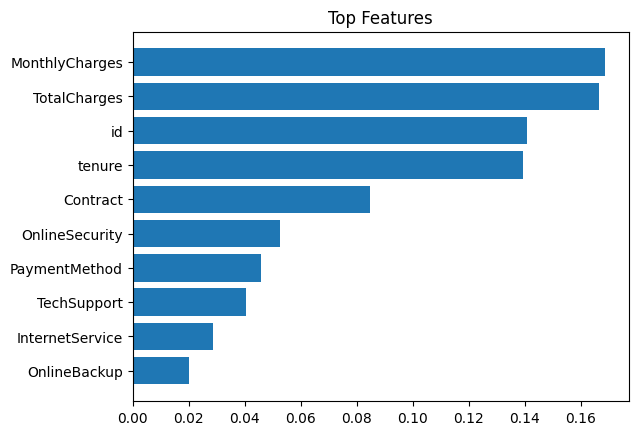

In [12]:
import matplotlib.pyplot as plt

importances = rf.feature_importances_
feature_names = X.columns

indices = np.argsort(importances)[-10:]

plt.figure()
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), feature_names[indices])
plt.title("Top Features")
plt.show()

In [13]:
test_df = pd.read_csv("test.csv")

# Apply same preprocessing
if "customerID" in test_df.columns:
    ids = test_df["customerID"]
    test_df = test_df.drop(columns=["customerID"])
else:
    ids = np.arange(len(test_df))

# Convert + fill
if "TotalCharges" in test_df.columns:
    test_df["TotalCharges"] = pd.to_numeric(test_df["TotalCharges"], errors="coerce")

test_df = test_df.fillna(test_df.median(numeric_only=True))

# Encode
for col in test_df.select_dtypes(include="object").columns:
    test_df[col] = label_encoders[col].transform(test_df[col])

# Scale
test_scaled = scaler.transform(test_df)

# Predict
preds = rf.predict(test_scaled)

submission = pd.DataFrame({
    "customerID": ids,
    "Churn": preds
})

submission.to_csv("submission.csv", index=False)
print("Submission file created!")

Submission file created!
